# Lab 4 — Intensity Transformations & Filtering in the Spatial Domain

This version is prepared to run in **VS Code / Jupyter** without Colab-only functions such as `cv2_imshow`.

> If the packages are not installed in your selected VS Code Python environment, run once in the terminal:
>
> `pip install numpy matplotlib scikit-image`


In [1]:
# Common imports used in the whole lab
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, io, color, img_as_ubyte

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Thresholding

Loaded image: lab4_cameraman.jpeg


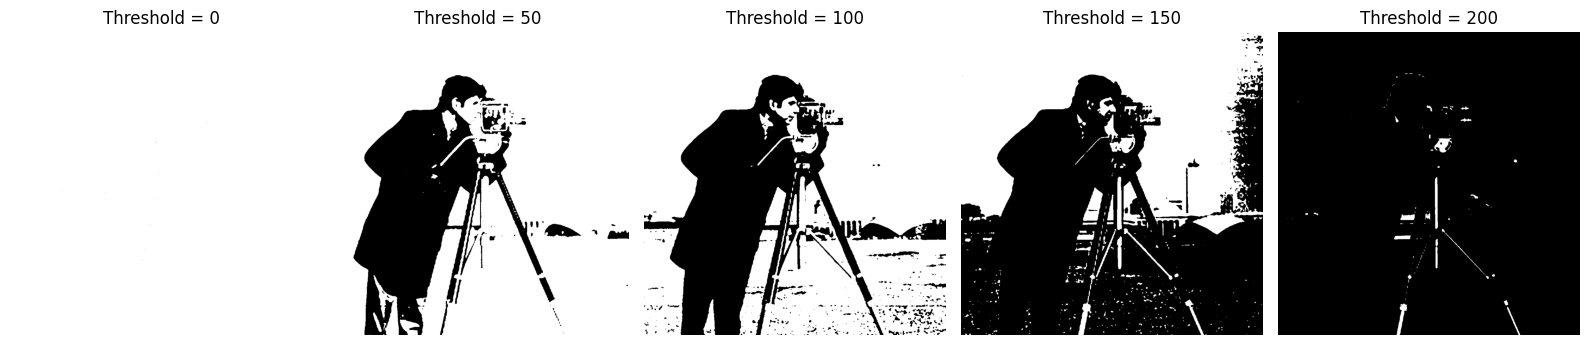

In [2]:
# Load the supplied cameraman image when it is in the same folder as this notebook.
# If the file is missing, use skimage's built-in cameraman image so the notebook still runs.

image_path = Path("lab4_cameraman.jpeg")

if image_path.exists():
    loaded_img = io.imread(image_path)
    if loaded_img.ndim == 3:
        img = img_as_ubyte(color.rgb2gray(loaded_img))
    else:
        img = img_as_ubyte(loaded_img)
    print(f"Loaded image: {image_path.name}")
else:
    img = data.camera()
    print("lab4_cameraman.jpeg was not found, so skimage.data.camera() is used.")

# Set threshold values
threshold_values = [0, 50, 100, 150, 200]

# Display thresholded images
fig, axes = plt.subplots(1, len(threshold_values), figsize=(16, 4))

for ax, threshold_value in zip(axes, threshold_values):
    thresh_img = np.where(img > threshold_value, 255, 0).astype(np.uint8)
    ax.imshow(thresh_img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Threshold = {threshold_value}")
    ax.axis("off")

plt.tight_layout()
plt.show()

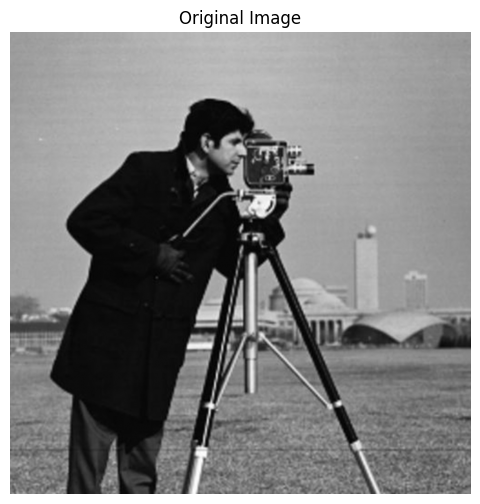

In [3]:
# Display the original grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Histograms

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


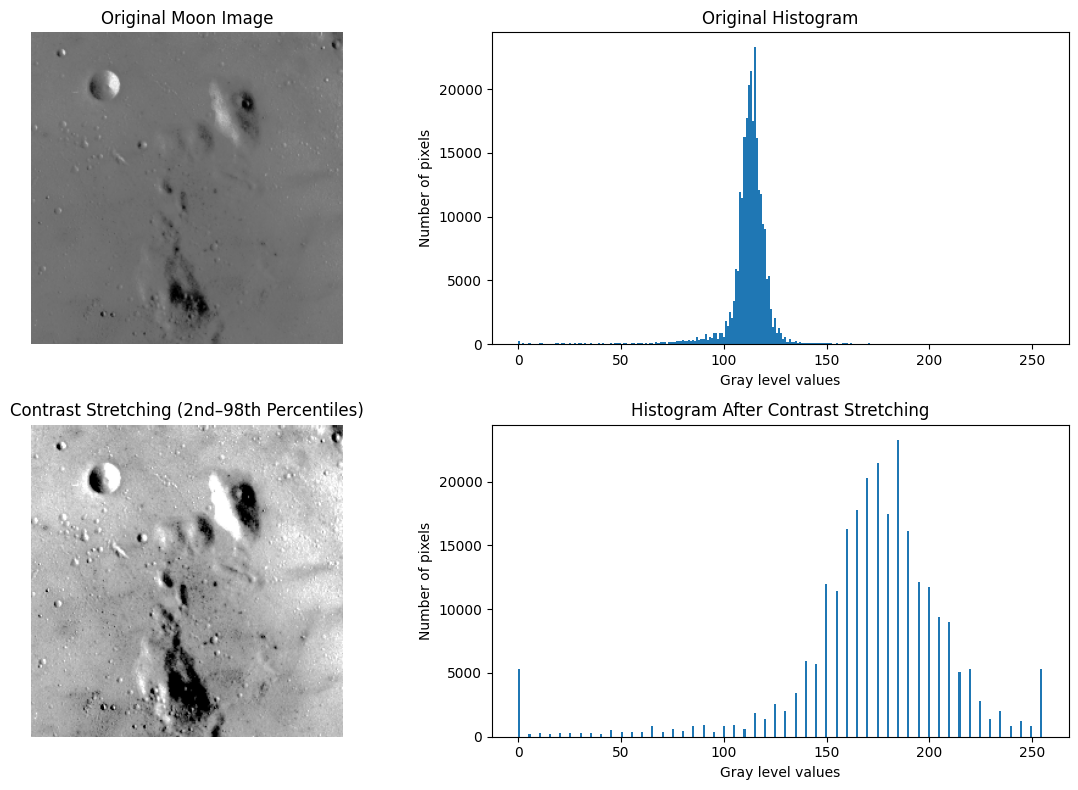

2nd percentile = 78.00
98th percentile = 129.00


In [4]:
# Original example: contrast stretching using the 2nd and 98th percentiles

moon = data.moon()

p2, p98 = np.percentile(moon, (2, 98))
moon_rescale_2_98 = exposure.rescale_intensity(moon, in_range=(p2, p98))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(moon, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Moon Image")
axes[0, 0].axis("off")

axes[0, 1].hist(moon.ravel(), bins=256, range=(0, 255))
axes[0, 1].set_title("Original Histogram")
axes[0, 1].set_xlabel("Gray level values")
axes[0, 1].set_ylabel("Number of pixels")

axes[1, 0].imshow(moon_rescale_2_98, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Contrast Stretching (2nd–98th Percentiles)")
axes[1, 0].axis("off")

axes[1, 1].hist(moon_rescale_2_98.ravel(), bins=256, range=(0, 255))
axes[1, 1].set_title("Histogram After Contrast Stretching")
axes[1, 1].set_xlabel("Gray level values")
axes[1, 1].set_ylabel("Number of pixels")

plt.tight_layout()
plt.show()

print(f"2nd percentile = {p2:.2f}")
print(f"98th percentile = {p98:.2f}")

# Tasks

**Task 1:** Using the same moon image, rescale intensity values to include all intensities that fall within the **3rd and 80th percentiles**, and plot the histogram.

**Task 2:** Using the same moon image and `exposure.equalize_hist`, display the image and its histogram after histogram equalization.

**Task 3:** Use the **rocket image as the reference** and the **chelsea image as the source** (from `skimage.data`) and implement histogram matching.


## Task 1 — Contrast Stretching (3rd–80th Percentiles)

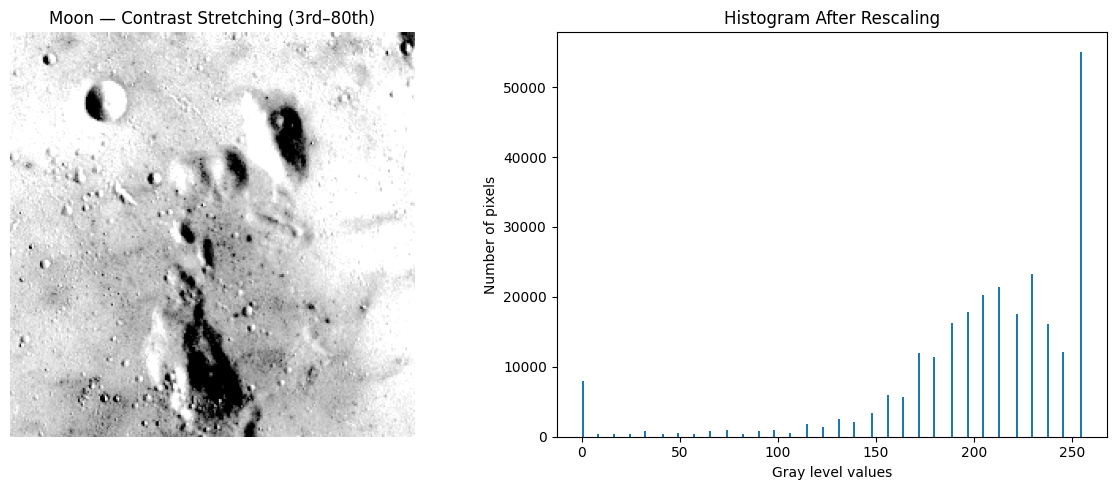

3rd percentile  = 87.00
80th percentile = 118.00


In [5]:
# Task 1
moon = data.moon()

# Find the intensity values at the 3rd and 80th percentiles
p3, p80 = np.percentile(moon, (3, 80))

# Rescale the image so [p3, p80] is stretched to the full output range
moon_rescale_3_80 = exposure.rescale_intensity(
    moon,
    in_range=(p3, p80)
)

# Display the rescaled image and its histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(moon_rescale_3_80, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Moon — Contrast Stretching (3rd–80th)")
axes[0].axis("off")

axes[1].hist(moon_rescale_3_80.ravel(), bins=256, range=(0, 255))
axes[1].set_title("Histogram After Rescaling")
axes[1].set_xlabel("Gray level values")
axes[1].set_ylabel("Number of pixels")

plt.tight_layout()
plt.show()

print(f"3rd percentile  = {p3:.2f}")
print(f"80th percentile = {p80:.2f}")

## Task 2 — Histogram Equalization

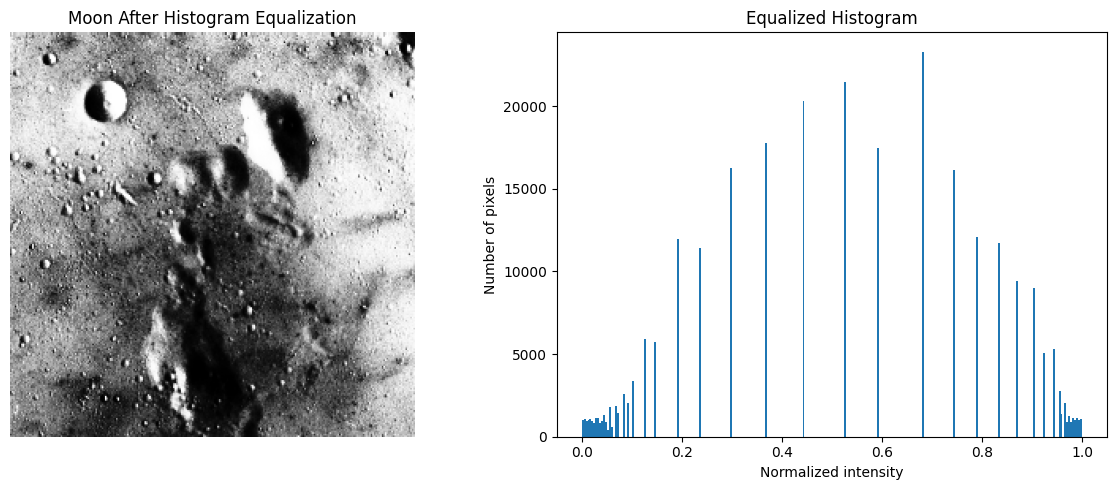

In [6]:
# Task 2
moon = data.moon()

# Histogram equalization
moon_equalized = exposure.equalize_hist(moon)

# equalize_hist returns floating-point values in the range [0, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(moon_equalized, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Moon After Histogram Equalization")
axes[0].axis("off")

axes[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1))
axes[1].set_title("Equalized Histogram")
axes[1].set_xlabel("Normalized intensity")
axes[1].set_ylabel("Number of pixels")

plt.tight_layout()
plt.show()

## Task 3 — Histogram Matching

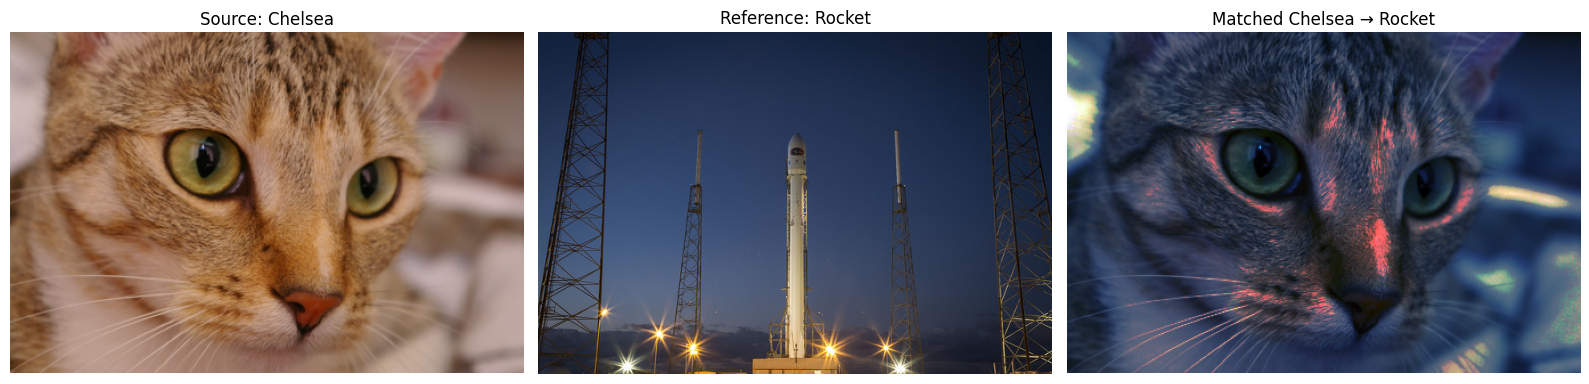

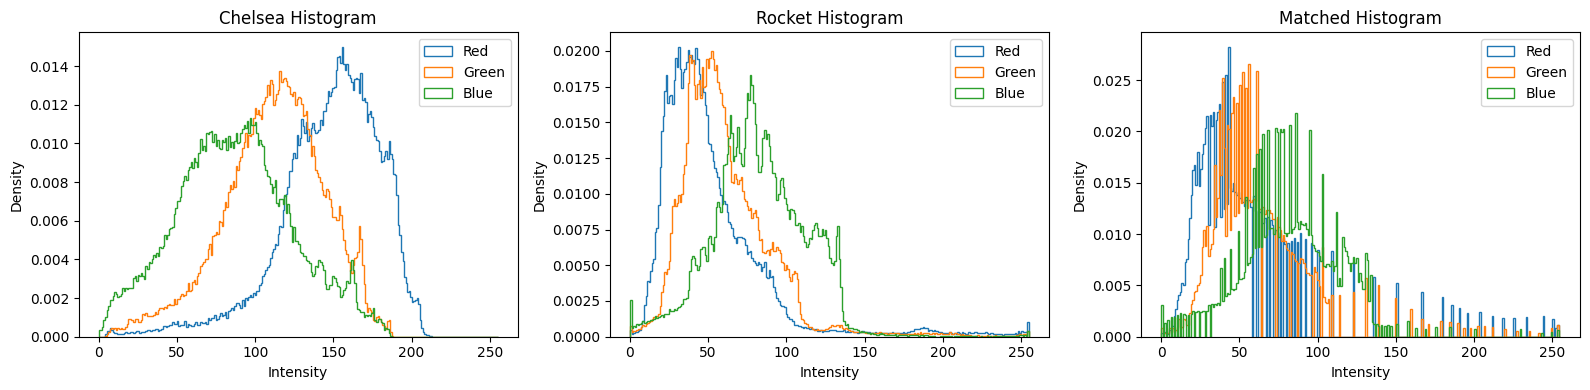

Histogram matching completed successfully.


In [7]:
# Task 3
# Source image: chelsea
# Reference image: rocket

source = data.chelsea()
reference = data.rocket()

# Match the histogram of chelsea to the histogram of rocket.
# channel_axis=-1 tells skimage that the last dimension contains RGB channels.
matched = exposure.match_histograms(
    source,
    reference,
    channel_axis=-1
)

# Display source, reference, and matched images
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(source)
axes[0].set_title("Source: Chelsea")
axes[0].axis("off")

axes[1].imshow(reference)
axes[1].set_title("Reference: Rocket")
axes[1].axis("off")

axes[2].imshow(np.clip(matched, 0, 255).astype(np.uint8))
axes[2].set_title("Matched Chelsea → Rocket")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Compare RGB histograms before and after matching
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

images = [source, reference, matched]
titles = ["Chelsea Histogram", "Rocket Histogram", "Matched Histogram"]
channel_names = ["Red", "Green", "Blue"]

for ax, image, title in zip(axes, images, titles):
    for channel in range(3):
        ax.hist(
            image[..., channel].ravel(),
            bins=256,
            range=(0, 255),
            histtype="step",
            density=True,
            label=channel_names[channel]
        )
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

print("Histogram matching completed successfully.")